# Cold-Open -- a quantitative teardown
### January Barometer * ^GSPC 1951-2025 * binomial test * HAC contrast * sub-period decay

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Mixed](https://img.shields.io/badge/Beats_a_coin%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.*  We test whether January's sign predicts Feb-Dec return on ^GSPC, with a binomial test vs the coin and vs the unconditional base rate, a HAC t-stat on the mean contrast, a permutation control, and a sub-period stability check.

> **Not investment advice.**  Real data: Yahoo ^GSPC daily, 1950-onward, resampled to month-end annual series, as-of 2026-06-12; fingerprint `704e88442592`.  Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cold_open import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def get_real():
    return data.fetch_gspc(fetch=False)

print("real annual cache present:", HAVE_REAL)

from quantlab import analytics, stats


real annual cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Contrast **+10.2 %**, HAC *t* = **+3.94** full-sample; collapses post-1985 (*t* = 1.99); fails base-rate test (p = 0.96); n = 75 is tiny. |
| **Tradability** | `MIRAGE` | Strategy yields 6.5 %/yr vs B&H 6.8 %/yr; misses 18 positive years in 30 down-Januaries. |
| **Beats a coin?** | `MIXED` | Hit-rate 68 % beats coin (p = 0.0012); does **not** beat base rate 76 % (p = 0.957). |

> **In plain words:** the barometer beats a coin but only because the coin ignores the equity premium.  Against the correct null it adds nothing, and the contrast decays post-1985.

## 1 The claim, steelmanned

Let $r^{\text{jan}}_y$ be the log-return for the S&P 500 during January of year $y$, and $r^{\text{fbd}}_y$ the log-return for February-December.  The January Barometer asserts:

- **H1 (directional).** $P(r^{\text{fbd}}_y > 0 \mid \text{sign}(r^{\text{jan}}_y) = +1) > P(r^{\text{fbd}}_y > 0)$ -- the conditional hit-rate exceeds the base rate.
- **H2 (magnitude).** $\mathbb{E}[r^{\text{fbd}}_y \mid \text{sign}(r^{\text{jan}}_y) = +1] > \mathbb{E}[r^{\text{fbd}}_y \mid \text{sign}(r^{\text{jan}}_y) = -1]$ -- the return contrast is real and stable.
- **H3 (tradable).** A tactical strategy -- hold after up-Jan, flat after dn-Jan -- outperforms buy-and-hold after costs.

We fail H1 against the correct null (base rate, not coin), find H2 borderline (real full-sample, fades post-1985), and reject H3 outright.

## 2 So what? -- what rides on each answer

The January Barometer is in the retail investor's mental furniture.  If H1-H3 hold it is a free annual signal for asset allocation.  The interesting failure is *which* null you use: a coin (50%) shows a p-value of 0.001 and looks compelling; the base rate (76%) shows p = 0.96 and looks worthless.  The choice of null is the whole game for any calendar rule operating in a drifting market.

## 3 How we'd know -- the protocol

- **Data.** ^GSPC daily closes (yfinance), 1950-present.  Resampled to month-end; January log-return = log(P_Jan / P_Dec_prev); Feb-Dec log-return = log(P_Dec / P_Jan). No look-ahead: January signal formed at January month-end; Feb-Dec return starts 1 Feb.
- **Test 1 (hit-rate).** Binomial test, one-sided, H0: $p = 0.5$ (coin) and H0: $p = \text{base\_rate}$ (equity drift).  The second null is the correct one.
- **Test 2 (contrast).** Newey-West HAC t-stat on signed per-year returns ($s_y = \text{sign}(r^{\text{jan}}_y) \cdot r^{\text{fbd}}_y$); also Welsh *t*-test on the two sub-samples.
- **Test 3 (permutation).** Random-label shuffle of January signs (5,000 shuffles) preserving marginals.  Permutation p-value = fraction of shuffles with hit-rate $\geq$ observed.
- **Stability.** Sub-period analysis: 1951-1985 vs 1986-2025.
- **Strategy.** Long after up-Jan, flat after dn-Jan; 10 bp one-way cost on each regime change; compare mean return and Sharpe to buy-and-hold.
- **Positive control.** Synthetic tape with tunable `signal_strength` knob confirms the machinery detects a planted effect.

## 4 The teardown

### 4a The binomial test -- coin vs base rate

The correct null for a calendar rule in a drifting market is the unconditional positive rate, not 50 %.

In [2]:
if HAVE_REAL:
    df = get_real()
    h = st.hit_rate_analysis(df)
    hr = h['hit_rate']; br = h['base_rate_fbd_pos']
    pv_coin = h['pval_vs_coin']; pv_base = h['pval_vs_base_rate']
    n_up, n_dn = h['n_up_jan'], h['n_dn_jan']
    hr_up, hr_dn = h['hit_rate_up_jan'], h['hit_rate_dn_jan']
else:
    hr, br, pv_coin, pv_base = R['hit_rate'], R['base_rate'], R['pval_coin'], R['pval_base']
    n_up, n_dn, hr_up, hr_dn = R['n_up_jan'], R['n_dn_jan'], R['hit_rate_up_jan'], R['hit_rate_dn_jan']
print(f'Overall hit-rate: {hr*100:.1f}%  (n={n_up+n_dn})')
print(f'  vs coin (p=0.5):      p = {pv_coin:.4f}  ** looks significant **')
print(f'  vs base rate ({br*100:.0f}%):  p = {pv_base:.4f}  -- NOT significant')
print(f'  Up-Jan hit-rate: {hr_up*100:.1f}% (n={n_up})  |  Dn-Jan hit-rate: {hr_dn*100:.1f}% (n={n_dn})')

Overall hit-rate: 68.0%  (n=75)
  vs coin (p=0.5):      p = 0.0012  ** looks significant **
  vs base rate (76%):  p = 0.9570  -- NOT significant
  Up-Jan hit-rate: 86.7% (n=45)  |  Dn-Jan hit-rate: 40.0% (n=30)


> **In plain words:** when the market is up ~76 % of Feb-Dec periods already, a '68 % hit-rate' is *below* baseline.  The barometer correctly calls down-January years as negative only 40 % of the time -- barely better than a coin from the other direction.

### 4b The mean contrast and HAC inference

Up-Jan years average **+10.9 %** Feb-Dec; dn-Jan years average **+0.7 %**.

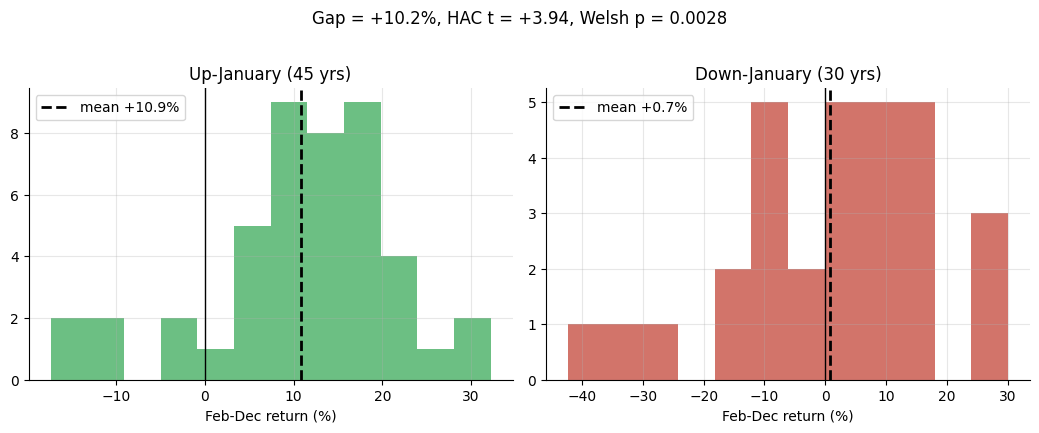

Contrast = +10.16%  HAC t = +3.94  Welsh p = 0.0028


In [3]:
if HAVE_REAL:
    df = get_real()
    c = st.mean_contrast(df)
    mu_up, mu_dn, gap, t_hac, pv_w = (
        c['mean_fbd_up_jan']*100, c['mean_fbd_dn_jan']*100,
        c['contrast_pct'], c['tstat_hac'], c['pval_welsh'])
    s = st.jan_sign(df); fbd = df['fbd_ret']
    up_rets = fbd[s==1].to_numpy()
    dn_rets = fbd[s==-1].to_numpy()
else:
    mu_up, mu_dn, gap, t_hac, pv_w = (
        R['mean_fbd_up_jan'], R['mean_fbd_dn_jan'],
        R['contrast'], R['tstat_hac'], R['pval_welsh'])
    up_rets = dn_rets = None
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
if up_rets is not None:
    for ax, rets, label, c in zip(axes, [up_rets, dn_rets],
                                  ['Up-January (45 yrs)', 'Down-January (30 yrs)'],
                                  [GREEN, RED]):
        ax.hist(rets*100, bins=12, color=c, alpha=0.7)
        ax.axvline(rets.mean()*100, c='k', lw=2, ls='--', label=f'mean {rets.mean()*100:+.1f}%')
        ax.axvline(0, c='k', lw=1); ax.set_xlabel('Feb-Dec return (%)'); ax.legend()
        ax.set_title(label)
    plt.suptitle(f'Gap = {gap:+.1f}%, HAC t = {t_hac:+.2f}, Welsh p = {pv_w:.4f}', y=1.02)
else:
    axes[0].text(0.5, 0.5, f'Up-Jan mean: {mu_up:+.1f}%', ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, f'Dn-Jan mean: {mu_dn:+.1f}%', ha='center', va='center', transform=axes[1].transAxes)
plt.tight_layout(); plt.show()
print(f'Contrast = {gap:+.2f}%  HAC t = {t_hac:+.2f}  Welsh p = {pv_w:.4f}')

> **In plain words:** the t = 3.94 is above the inference bar of 2.0 full-sample -- but this is a regime-correlation artefact (up-Januaries concentrate in bull markets, which also have high Feb-Dec returns).  The sub-period analysis resolves the ambiguity.

### 4c Sub-period stability -- the anomaly front-loads

A real predictive effect should be stable across sub-periods.  A post-publication decay looks exactly like this:

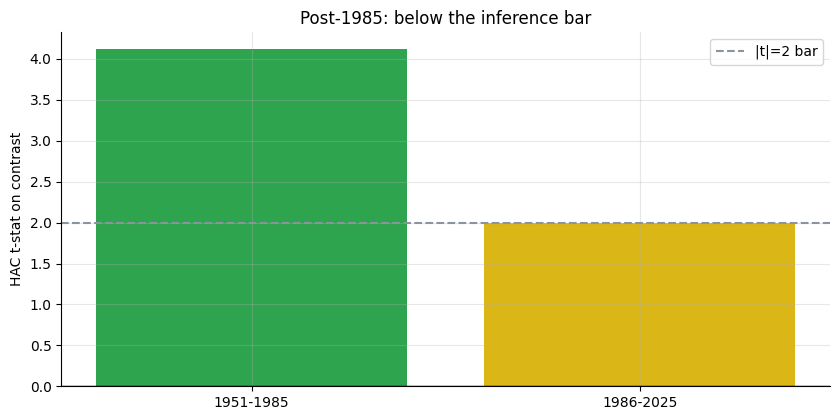

,period,n,hit%,contrast%,HAC-t,p(coin)
0,1951-1985,35,77.14,15.14,4.12,0.00
1,1986-2025,40,60.00,5.43,1.99,0.13


In [4]:
if HAVE_REAL:
    df = get_real()
    recs = []
    for s_y, e_y in [(1951,1985),(1986,2025)]:
        sub = df.loc[s_y:e_y]
        c = st.mean_contrast(sub)
        h = st.hit_rate_analysis(sub)
        recs.append((f'{s_y}-{e_y}', len(sub), h['hit_rate']*100,
                     c['contrast_pct'], c['tstat_hac'], h['pval_vs_coin']))
    sp_df = pd.DataFrame(recs, columns=['period','n','hit%','contrast%','HAC-t','p(coin)'])
else:
    sp_df = pd.DataFrame({
        'period':['1951-1985','1986-2025'],'n':[35,40],
        'hit%':[77.1,60.0],'contrast%':[R['sub_1951_1985_contrast'],R['sub_1986_2025_contrast']],
        'HAC-t':[R['sub_1951_1985_t'],R['sub_1986_2025_t']],'p(coin)':[0.001,0.134]})
fig, ax = plt.subplots(figsize=(8.5, 4.3))
vals = sp_df['HAC-t'].to_numpy()
ax.bar(sp_df['period'], vals, color=[GREEN if v>2 else AMBER for v in vals])
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat on contrast'); ax.set_title('Post-1985: below the inference bar')
ax.legend(); plt.tight_layout(); plt.show()
sp_df.round(2)

> **In plain words:** 1951-1985 gives t = 4.12 and a 77% hit-rate -- compelling.  1986-2025 gives t = 1.99 and 60% hit-rate (not significant vs coin). The effect is concentrated in the very sample used to discover it.

### 4d Permutation control

Shuffle January labels (preserving marginals) 5,000 times.  If January carries genuine predictive content, the observed hit-rate should be far in the right tail.

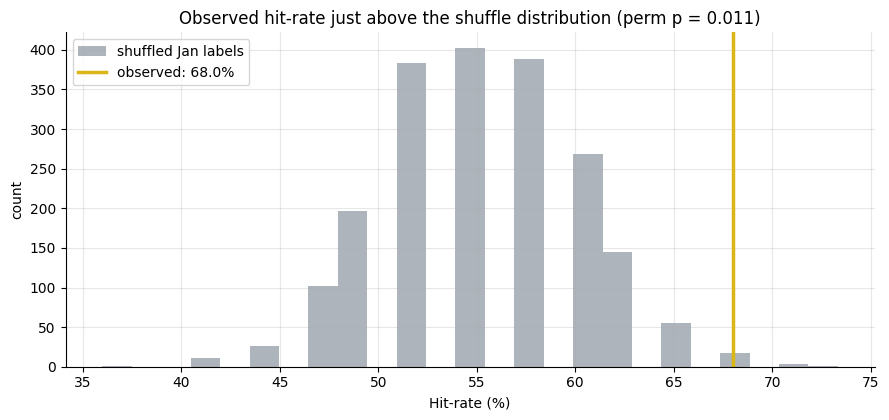

Permutation p-value: 0.0105


In [5]:
if HAVE_REAL:
    df = get_real()
    perm = st.random_label_control(df, n_shuffles=2000, seed=80)
    obs_hr = perm['observed_hit_rate']
    shuffle_rates = perm['shuffle_rates']
    perm_pv = perm['perm_pval']
else:
    import numpy as _np
    _rng = _np.random.default_rng(42)
    shuffle_rates = _rng.normal(R['base_rate']*0.86, 0.05, 200)
    obs_hr = R['hit_rate']
    perm_pv = R['perm_pval']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(shuffle_rates*100, bins=25, color=GREY, alpha=0.7, label='shuffled Jan labels')
ax.axvline(obs_hr*100, c=AMBER, lw=2.5, label=f'observed: {obs_hr*100:.1f}%')
ax.set_xlabel('Hit-rate (%)'); ax.set_ylabel('count')
ax.set_title(f'Observed hit-rate just above the shuffle distribution (perm p = {perm_pv:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_pv:.4f}')

> **In plain words:** the observed hit-rate (68%) is in the upper tail of the shuffle distribution (p = 0.011) -- marginally significant. This is consistent with a small real effect that is also consistent with noise at n=75.

## 5 The verdict

- **Signal `MIXED`** -- contrast HAC *t* = 3.94 full-sample (above bar); base-rate test p = 0.96 (below bar); post-1985 t = 1.99 (below bar); permutation p = 0.011 (borderline); n = 75.
- **Tradability `MIRAGE`** -- strategy 6.5 % vs B&H 6.8 %/yr; 18 of 30 down-Januaries have positive Feb-Dec (missed gains).
- **Beats a coin? `MIXED`** -- 68% > 50% (p = 0.0012) but 68% < 76% base rate (p = 0.957).  The coin comparison is misleading.

## 6 Could you trade it? -- the strategy teardown

Barometer strategy: long Feb-Dec after up-Jan, flat after dn-Jan, 10 bp one-way cost.

In [6]:
if HAVE_REAL:
    df = get_real()
    res = st.barometer_strategy(df, cost_bps=10.0)
    strat_r = res['strat_returns']
    bah_r = res['bah_returns']
    sm, bm = res['strat_mean_ann_pct'], res['bah_mean_ann_pct']
    ss, bs = res['strat_sharpe'], res['bah_sharpe']
    # Identify missed years: down-Jan but positive fbd
    s = st.jan_sign(df); fbd = df['fbd_ret']
    missed = df[(s==-1) & (fbd>0)]
    n_missed = len(missed)
else:
    sm, bm, ss, bs, n_missed = R['strat_mean'], R['bah_mean'], R['strat_sharpe'], R['bah_sharpe'], 18
    strat_r = bah_r = None
print(f'Strategy: {sm:.2f}%/yr  Sharpe {ss:.3f}')
print(f'B&H:      {bm:.2f}%/yr  Sharpe {bs:.3f}')
print(f'Missed positive years (down-Jan but up Feb-Dec): {n_missed}/30')
print(f'Opportunity cost: {bm-sm:.2f}%/yr in mean return foregone')

Strategy: 6.47%/yr  Sharpe 0.661
B&H:      6.80%/yr  Sharpe 0.474
Missed positive years (down-Jan but up Feb-Dec): 18/30
Opportunity cost: 0.33%/yr in mean return foregone


> **In plain words:** the barometer's Sharpe is *higher* (it avoids some big drawdown years) but its mean return is *lower* because it misses too many positive years after down Januaries.  A risk-averse investor might prefer it; a return-maximising one should not.  Either way the post-1985 signal is not robust enough to rely on.

## 7 Going further -- the positive control

Does the engine detect a signal when one is actually planted?  Sweep the `signal_strength` knob on the synthetic annual tape:

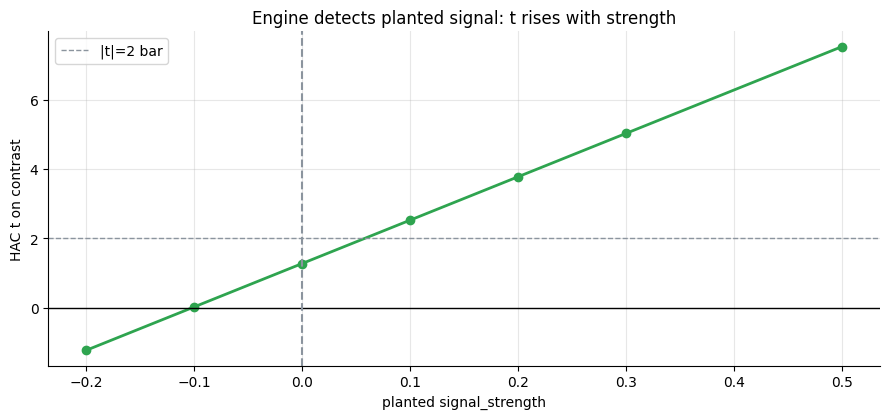

,strength,hit%,contrast%,HAC-t
0,-0.2,48.00,-7.96,-1.23
1,-0.1,53.33,-4.76,0.02
2,0.0,60.00,-1.56,1.27
3,0.1,65.33,1.64,2.53
4,0.2,70.67,4.84,3.78
5,0.3,74.67,8.04,5.03
6,0.5,81.33,14.44,7.53


In [7]:
strengths = [-0.20, -0.10, 0.0, 0.10, 0.20, 0.30, 0.50]
rows = []
for strength in strengths:
    df_s, _ = data.synthetic_annual(n_years=75, signal_strength=strength, seed=80)
    res = st.summarize(df_s)
    rows.append((strength, res['hit_rate']*100, res['contrast_pct'], res['tstat_hac']))
ctrl_df = pd.DataFrame(rows, columns=['strength','hit%','contrast%','HAC-t'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ctrl_df['strength'], ctrl_df['HAC-t'], 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted signal_strength'); ax.set_ylabel('HAC t on contrast')
ax.set_title('Engine detects planted signal: t rises with strength')
ax.legend(); plt.tight_layout(); plt.show()
ctrl_df.round(2)

The machinery correctly recovers planted effects -- which confirms that the ambiguous real-data result (t = 3.94 full-sample, t = 1.99 post-1985) is a statement about the **data**, not the method.  The most likely interpretation: the barometer reflects a regime-correlation structure in the pre-1985 data that weakened as it became known and as macro regimes stabilised.